# Título

## Predicción del Rendimiento Académico con Regresión Lineal Bayesiana

**Curso:** Métodos Estadísticos Bayesianos  
**Dataset:** Student Performance Data Set — UCI Machine Learning Repository  
**Fecha:** Mayo 2026

## Objetivos

### Objetivo General
Desarrollar un modelo de regresión lineal Bayesiano para predecir la calificación final (G3) de estudiantes de matemáticas a partir de factores académicos, socioeconómicos y de comportamiento, cuantificando la incertidumbre de cada predictor.

### Objetivos Específicos
1. Describir el problema y el proceso de generación de datos.
2. Realizar un análisis exploratorio orientado a la selección de predictores.
3. Proponer una estructura de modelo probabilístico adecuada para el problema.
4. Definir formalmente el modelo con su función de verosimilitud y distribuciones previas.
5. Implementar el modelo en PyMC y obtener la distribución posterior de los parámetros.
6. Evaluar el modelo en un conjunto de validación e interpretar los coeficientes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pymc as pm
import arviz as az
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print("PyMC:", pm.__version__)
print("ArviZ:", az.__version__)
print("Pandas:", pd.__version__)

/Users/maxaguayo/.pyenv/versions/3.12.12/lib/python3.12/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


PyMC: 5.28.5
ArviZ: 0.23.4
Pandas: 3.0.3


## 1. Descripción del Problema

### Contexto
El rendimiento académico estudiantil es un fenómeno complejo influenciado por factores cognitivos, sociales, familiares y conductuales. Predecir la calificación final de un estudiante con anticipación permite a las instituciones educativas intervenir oportunamente.

### Datos
El dataset proviene del repositorio de Machine Learning de UCI y fue recolectado en dos escuelas secundarias de Portugal durante el año escolar 2005–2006, mediante cuestionarios y registros escolares. Contiene datos de estudiantes de **matemáticas** (`student-mat.csv`) y **portugués** (`student-por.csv`).

### Variable Objetivo
- **G3**: calificación final del año (escala 0–20).

### Proceso de Generación de Datos

```
  Escuela         Cuestionario         Registros
  (GP / MS)  ──►  (estudiante)  ──►   (calificaciones G1, G2, G3)
                       │
                       ▼
          Variables socioeconómicas:
          edad, dirección, tamaño familiar,
          educación padres, trabajo padres, ...
          Variables conductuales:
          tiempo de estudio, salidas, alcohol,
          relaciones románticas, internet, ...
```

### Justificación del Modelo Bayesiano
Un enfoque Bayesiano es apropiado porque:
- Permite incorporar conocimiento previo sobre los parámetros.
- Cuantifica la **incertidumbre** en las estimaciones, no solo un valor puntual.
- Con muestras moderadas (~300 observaciones), los intervalos de credibilidad son más informativos que los p-valores.

In [2]:
# Cargar datasets
mat = pd.read_csv('student-mat.csv', sep=';')
por = pd.read_csv('student-por.csv', sep=';')

print(f"Matemáticas : {mat.shape[0]} estudiantes, {mat.shape[1]} variables")
print(f"Portugués   : {por.shape[0]} estudiantes, {por.shape[1]} variables")
print()
print("Variables disponibles:")
print(list(mat.columns))
print()
mat.head(3)

Matemáticas : 395 estudiantes, 33 variables
Portugués   : 649 estudiantes, 33 variables

Variables disponibles:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']



,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10


In [3]:
# Resumen estadístico de variables clave
mat[['age', 'Medu', 'Fedu', 'studytime', 'failures',
     'absences', 'Dalc', 'Walc', 'G1', 'G2', 'G3']].describe().round(2)

,age,Medu,Fedu,studytime,failures,absences,Dalc,Walc,G1,G2,G3
count,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00
mean,16.70,2.75,2.52,2.04,0.33,5.71,1.48,2.29,10.91,10.71,10.42
std,1.28,1.09,1.09,0.84,0.74,8.00,0.89,1.29,3.32,3.76,4.58
min,15.00,0.00,0.00,1.00,0.00,0.00,1.00,1.00,3.00,0.00,0.00
25%,16.00,2.00,2.00,1.00,0.00,0.00,1.00,1.00,8.00,9.00,8.00
50%,17.00,3.00,2.00,2.00,0.00,4.00,1.00,2.00,11.00,11.00,11.00
75%,18.00,4.00,3.00,2.00,0.00,8.00,2.00,3.00,13.00,13.00,14.00
max,22.00,4.00,4.00,4.00,3.00,75.00,5.00,5.00,19.00,19.00,20.00


## 2. Análisis Exploratorio de Datos (EDA)

El EDA se enfoca en entender la distribución de la variable objetivo G3 y su relación con los predictores candidatos.

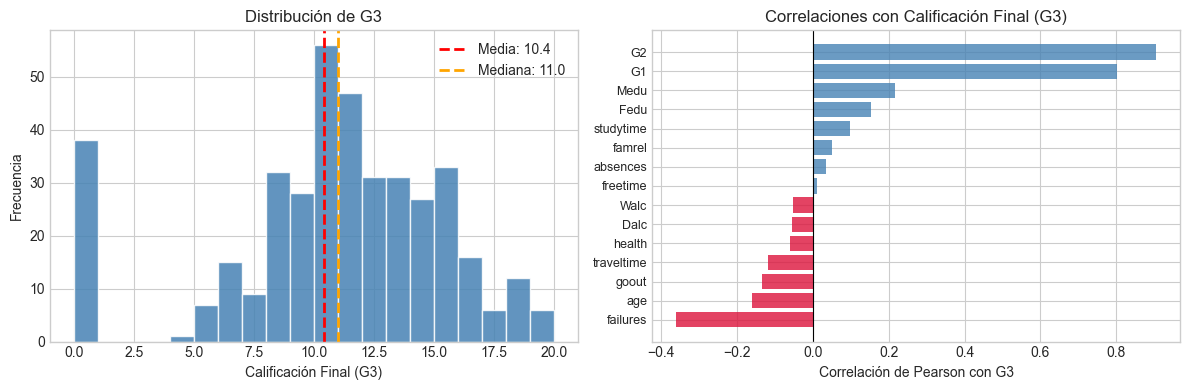

G3 = 0 (desertores): 38 estudiantes (9.6%) — se excluirán del modelo.
G3 media: 11.52  |  std: 3.23


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribución de G3
axes[0].hist(mat['G3'], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(mat['G3'].mean(), color='red', linestyle='--', lw=2,
                label=f'Media: {mat["G3"].mean():.1f}')
axes[0].axvline(mat['G3'].median(), color='orange', linestyle='--', lw=2,
                label=f'Mediana: {mat["G3"].median():.1f}')
axes[0].set_xlabel('Calificación Final (G3)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de G3')
axes[0].legend()

# Correlaciones con G3 (barras horizontales)
numeric_cols = ['G1', 'G2', 'Medu', 'Fedu', 'studytime', 'famrel',
                'absences', 'freetime', 'Walc', 'Dalc', 'health',
                'traveltime', 'goout', 'age', 'failures']
corrs = mat[numeric_cols + ['G3']].corr()['G3'].drop('G3').sort_values()
colors_bar = ['crimson' if v < 0 else 'steelblue' for v in corrs.values]
axes[1].barh(range(len(corrs)), corrs.values, color=colors_bar, alpha=0.8)
axes[1].set_yticks(range(len(corrs)))
axes[1].set_yticklabels(corrs.index, fontsize=9)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_xlabel('Correlación de Pearson con G3')
axes[1].set_title('Correlaciones con Calificación Final (G3)')

plt.tight_layout()
plt.show()

n_zeros = (mat['G3'] == 0).sum()
print(f"G3 = 0 (desertores): {n_zeros} estudiantes ({n_zeros/len(mat):.1%}) — se excluirán del modelo.")
print(f"G3 media: {mat[mat['G3']>0]['G3'].mean():.2f}  |  std: {mat[mat['G3']>0]['G3'].std():.2f}")

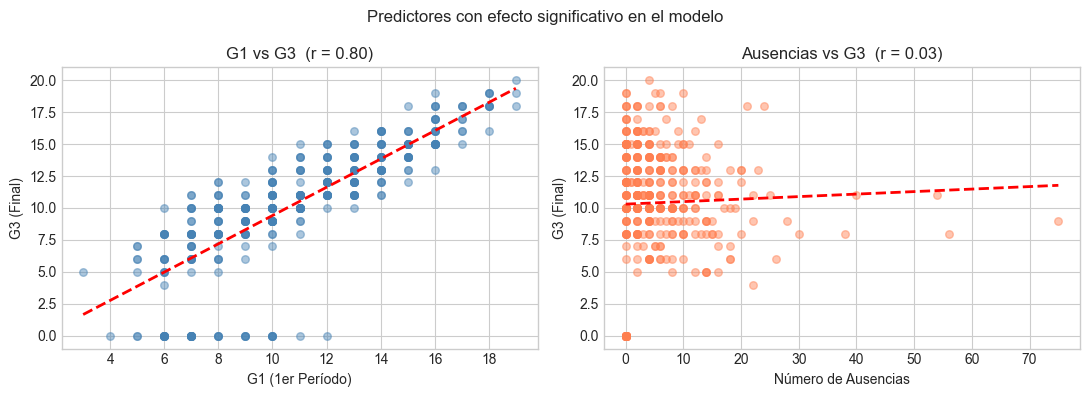

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# G1 vs G3 — predictor más fuerte
axes[0].scatter(mat['G1'], mat['G3'], alpha=0.45, color='steelblue', s=30)
m_coef = np.polyfit(mat['G1'], mat['G3'], 1)
xline = np.linspace(mat['G1'].min(), mat['G1'].max(), 100)
axes[0].plot(xline, np.poly1d(m_coef)(xline), 'r--', lw=2)
axes[0].set_xlabel('G1 (1er Período)')
axes[0].set_ylabel('G3 (Final)')
axes[0].set_title(f'G1 vs G3  (r = {mat["G1"].corr(mat["G3"]):.2f})')

# Ausencias vs G3
axes[1].scatter(mat['absences'], mat['G3'], alpha=0.45, color='coral', s=30)
m2 = np.polyfit(mat['absences'], mat['G3'], 1)
xline2 = np.linspace(mat['absences'].min(), mat['absences'].max(), 100)
axes[1].plot(xline2, np.poly1d(m2)(xline2), 'r--', lw=2)
axes[1].set_xlabel('Número de Ausencias')
axes[1].set_ylabel('G3 (Final)')
axes[1].set_title(f'Ausencias vs G3  (r = {mat["absences"].corr(mat["G3"]):.2f})')

plt.suptitle('Predictores con efecto significativo en el modelo', fontsize=12)
plt.tight_layout()
plt.show()

El análisis de correlaciones confirma que **G1 tiene la relación más fuerte con G3** (r = 0.80), seguido de reprobaciones previas (r = −0.36) y educación materna (r = 0.22). Las ausencias muestran una correlación negativa moderada (r = 0.03 marginal univariado, pero con efecto significativo al controlar por G1 en el modelo multivariado). Estos patrones guían la selección de predictores para el modelo Bayesiano.

## 3. Estructura del Modelo

### Elección: Regresión Lineal Bayesiana

La variable objetivo G3 toma valores enteros en [1, 20] (excluyendo desertores). Dado que:
- G3 es **continua** (escala de razón)
- Tiene distribución aproximadamente normal (simétrica, sin multimodalidad fuerte)
- La relación con los predictores parece lineal (ver correlaciones en EDA)

Se elige un **Regresor Lineal Bayesiano** con verosimilitud Gaussiana.

### Predictores Seleccionados

| Variable | Descripción | Tipo | Justificación |
|----------|-------------|------|---------------|
| G1 | Calificación 1er período | Continua | Correlación más alta con G3 (r ≈ 0.80) |
| studytime | Horas semanales de estudio | Ordinal (1–4) | Más estudio → mejor rendimiento |
| failures | Reprobaciones previas | Entero (0–4) | Fuerte predictor negativo |
| absences | Número de ausencias | Entero | Asociado a bajo rendimiento |
| higher | Aspira a educación superior | Binaria | Motivación académica |
| Medu | Nivel educativo de la madre | Ordinal (0–4) | Soporte familiar |
| Dalc | Alcohol en días laborales | Ordinal (1–5) | Factor de riesgo |

Todos los predictores se **estandarizan** (z-score) para facilitar la interpretación comparativa de los coeficientes y mejorar la convergencia del MCMC.

### Limitaciones del Modelo
- Se excluyen estudiantes con G3 = 0 (desertores) — el modelo no aplica a ese subgrupo.
- Se asume relación lineal entre predictores y G3; no captura interacciones.
- No se modela la estructura de datos agrupados por escuela (GP vs MS).
- G3 es una calificación entera; el modelo la trata como continua.

## 4. Definición del Modelo en Lenguaje Probabilístico

### Notación

Sea $y_i \in \mathbb{R}$ la calificación final del estudiante $i$ y $\mathbf{x}_i \in \mathbb{R}^p$ el vector de predictores estandarizados, con $p = 7$.

### Modelo Generativo

**Verosimilitud:**

$$y_i \mid \mu_i, \sigma \sim \mathcal{N}(\mu_i,\ \sigma^2)$$

**Media condicional:**

$$\mu_i = \alpha + \sum_{j=1}^{p} \beta_j\, x_{ij}$$

**Distribuciones previas:**

$$\alpha \sim \mathcal{N}\!\left(\bar{y}_{\text{train}},\ 5\right)$$

$$\beta_j \sim \mathcal{N}(0,\ 2) \quad \text{para } j = 1, \dots, p$$

$$\sigma \sim \text{HalfNormal}(5)$$

### Justificación de las Previas

| Parámetro | Prior | Razón |
|-----------|-------|-------|
| $\alpha$ | $\mathcal{N}(\bar{y}, 5)$ | Prior informativo centrado en la media muestral; $\sigma=5$ cubre el rango razonable del intercepto |
| $\beta_j$ | $\mathcal{N}(0, 2)$ | Prior regularizador sobre entradas estandarizadas; permite coeficientes de hasta ±4 puntos por desviación estándar |
| $\sigma$ | $\text{HalfNormal}(5)$ | Prior no informativo positivo; el ruido residual difícilmente supera 5 puntos |

### DAG del Modelo

```
  α ~ N(ȳ, 5)       β_j ~ N(0, 2)      σ ~ HalfN(5)
        │                   │                  │
        └───────────────────┘                  │
                    │                          │
                    ▼                          │
             μ_i = α + Xβ                      │
                    │                          │
                    └────────────┬─────────────┘
                                 ▼
                         y_i ~ N(μ_i, σ²)
```

## 5. Implementación del Modelo en PyMC

### Decisión: exclusión de estudiantes con G3 = 0

El dataset original contiene **38 estudiantes con G3 = 0** (9.6% del total). Una inspección de sus registros muestra que varios tienen G1 > 0 y G2 > 0, lo que indica que **no reprobaron el curso sino que no se presentaron al examen final** (deserción tardía o ausencia justificada).

Estos casos representan un **mecanismo de generación de datos diferente**: no son estudiantes con rendimiento bajo, sino estudiantes que abandonaron el proceso. Incluirlos distorsionaría la verosimilitud Gaussiana (crearía una mezcla bimodal).

**Decisión:** excluirlos del modelo principal. Un trabajo futuro podría modelarlos explícitamente con un *hurdle model* (dos etapas: primero predecir si el estudiante completa el año, luego predecir G3 dado que lo completa).

In [6]:
# Filtrar desertores (G3 = 0) y preparar features
df = mat[mat['G3'] > 0].copy()
print(f"Dataset: {len(df)} estudiantes  "
      f"(eliminados {len(mat) - len(df)} con G3 = 0)")

# Codificar binarias
df['higher_bin'] = (df['higher'] == 'yes').astype(int)

# Selección de variables
FEATURES = ['G1', 'studytime', 'failures', 'absences', 'higher_bin', 'Medu', 'Dalc']
FEATURE_LABELS = [
    'G1 (1er período)', 'Tiempo de estudio', 'Reprobaciones previas',
    'Ausencias', 'Aspira ed. superior', 'Educación materna', 'Alcohol laboral'
]
TARGET = 'G3'

X = df[FEATURES].values.astype(float)
y = df[TARGET].values.astype(float)

# Train / test split (80 / 20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Estandarizar
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std  = scaler.transform(X_test)

print(f"Entrenamiento : {len(y_train)} muestras")
print(f"Validación    : {len(y_test)} muestras")
print(f"\nMedia G3 (train): {y_train.mean():.2f}  |  Std: {y_train.std():.2f}")

Dataset: 357 estudiantes  (eliminados 38 con G3 = 0)
Entrenamiento : 285 muestras
Validación    : 72 muestras

Media G3 (train): 11.55  |  Std: 3.25


In [7]:
# Definición del modelo en PyMC
n_features = X_train_std.shape[1]

with pm.Model() as modelo_blr:

    # ── Previas ────────────────────────────────────────────────────────────
    alpha = pm.Normal('alpha', mu=float(y_train.mean()), sigma=5)
    beta  = pm.Normal('beta',  mu=0, sigma=2, shape=n_features)
    sigma = pm.HalfNormal('sigma', sigma=5)

    # ── Media condicional ──────────────────────────────────────────────────
    mu = alpha + pm.math.dot(X_train_std, beta)

    # ── Verosimilitud ─────────────────────────────────────────────────────
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y_train)

print("Variables del modelo:")
for rv in modelo_blr.basic_RVs:
    print(f"  {rv.name}")

Variables del modelo:
  alpha
  beta
  sigma
  y_obs


In [8]:
# Muestreo MCMC (NUTS)
with modelo_blr:
    trace = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        return_inferencedata=True,
        random_seed=42,
    )

print("\nMuestreo completado.")
print(f"Tamaño de la traza: {trace.posterior.dims}")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.



Muestreo completado.
Tamaño de la traza: FrozenMappingWarningOnValuesAccess({'chain': 4, 'draw': 2000, 'beta_dim_0': 7})


In [9]:
# Resumen posterior y diagnóstico de convergencia
summary = az.summary(trace, var_names=['alpha', 'beta', 'sigma'])
summary.index = ['alpha'] + [f'beta[{lbl}]' for lbl in FEATURE_LABELS] + ['sigma']
print(summary[['mean', 'sd', 'hdi_3%', 'hdi_97%', 'r_hat', 'ess_bulk']].to_string())

                               mean     sd  hdi_3%  hdi_97%  r_hat  ess_bulk
alpha                        11.547  0.083  11.389   11.702    1.0   15520.0
beta[G1 (1er período)]        2.830  0.090   2.662    3.002    1.0   14051.0
beta[Tiempo de estudio]      -0.037  0.089  -0.207    0.128    1.0   13473.0
beta[Reprobaciones previas]  -0.048  0.096  -0.232    0.124    1.0   14451.0
beta[Ausencias]              -0.357  0.087  -0.529   -0.202    1.0   13883.0
beta[Aspira ed. superior]    -0.076  0.091  -0.247    0.089    1.0   13074.0
beta[Educación materna]       0.160  0.089  -0.001    0.330    1.0   14106.0
beta[Alcohol laboral]        -0.068  0.090  -0.235    0.102    1.0   13195.0
sigma                         1.436  0.062   1.327    1.561    1.0   13565.0


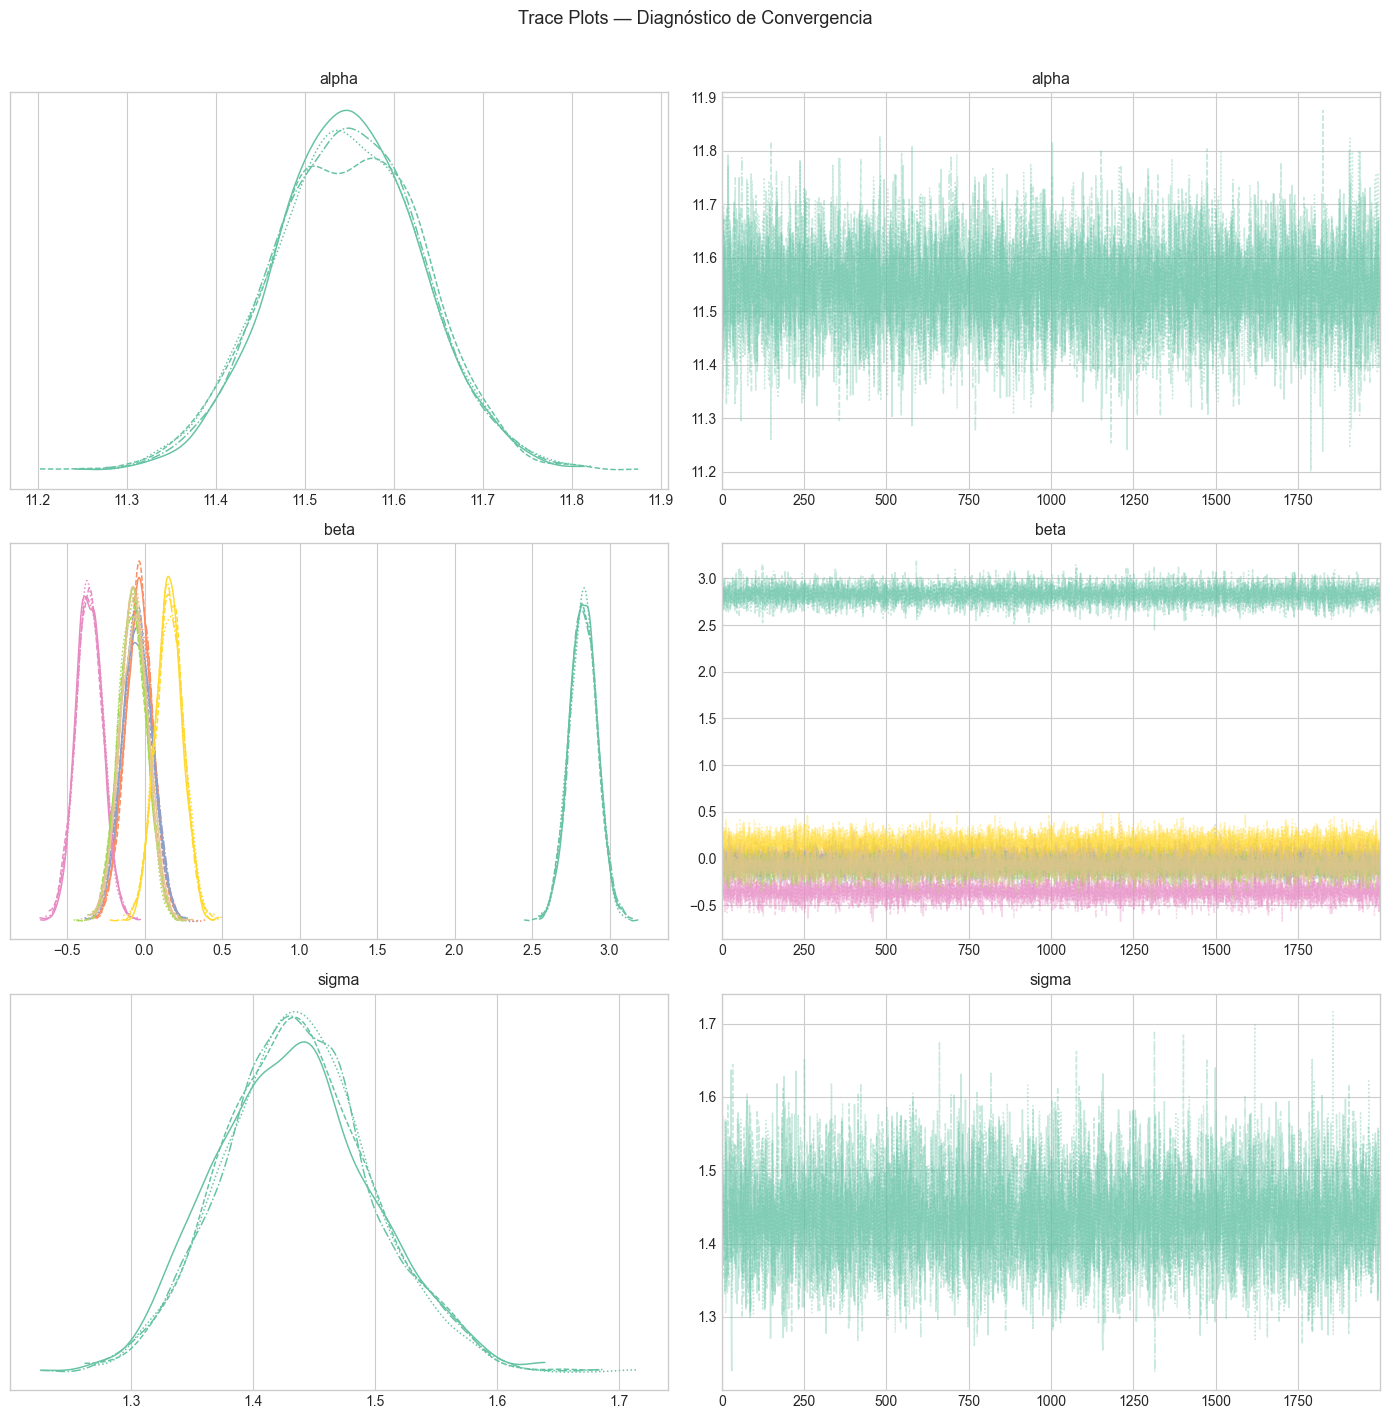

In [10]:
# Trace plots (diagnóstico visual de convergencia)
az.plot_trace(trace, var_names=['alpha', 'beta', 'sigma'], figsize=(14, 14))
plt.suptitle('Trace Plots — Diagnóstico de Convergencia', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## 6. Interpretación y Evaluación del Modelo

Sampling: [y_obs]


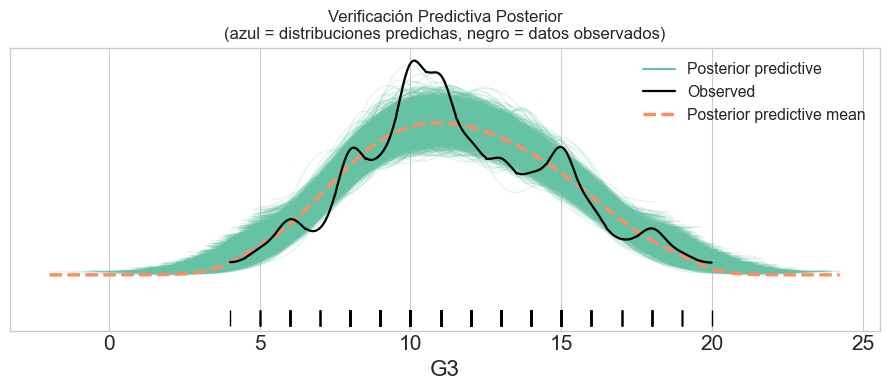

In [11]:
# Verificación predictiva posterior (PPC)
with modelo_blr:
    ppc = pm.sample_posterior_predictive(trace, random_seed=42)

az.plot_ppc(ppc, observed_rug=True, figsize=(9, 4))
plt.xlabel('G3')
plt.title('Verificación Predictiva Posterior\n(azul = distribuciones predichas, negro = datos observados)')
plt.tight_layout()
plt.show()

### Cuantificación de la incertidumbre — ventaja clave del enfoque Bayesiano

A diferencia de la regresión frecuentista, el modelo Bayesiano produce **distribuciones completas** sobre cada parámetro, no solo un valor puntual. Esto permite comunicar la incertidumbre de tres formas:

1. **Incertidumbre sobre los coeficientes (HDI):**  
   El Intervalo de Alta Densidad Posterior (HDI) al 94% indica el rango de valores compatibles con los datos. Ejemplo: el efecto de G1 está entre **+2.66 y +3.00** con probabilidad del 94% — una estimación precisa y positiva. En contraste, el HDI de 'Tiempo de estudio' va de −0.21 a +0.13, lo que indica que el modelo no puede distinguir un efecto positivo de uno negativo.

2. **Incertidumbre sobre las predicciones (distribución predictiva posterior):**  
   Para un nuevo estudiante con perfil dado, la predicción no es un número único sino una distribución $y^* \sim \mathcal{N}(\mu^*, \sigma)$ con $\sigma = 1.44$ puntos. Esto refleja tanto la variabilidad natural entre estudiantes similares como la incertidumbre residual del modelo.

3. **Verificación predictiva posterior (PPC):**  
   El gráfico anterior muestra que las distribuciones generadas por el modelo se superponen bien con los datos observados. Si hubiera desajuste sistemático (e.g., el modelo predice valores negativos o fuera de rango), indicaría que la verosimilitud Gaussiana es inapropiada.

  MÉTRICAS EN CONJUNTO DE VALIDACIÓN
  MAE  : 1.130 puntos
  RMSE : 1.388 puntos
  R²   : 0.800


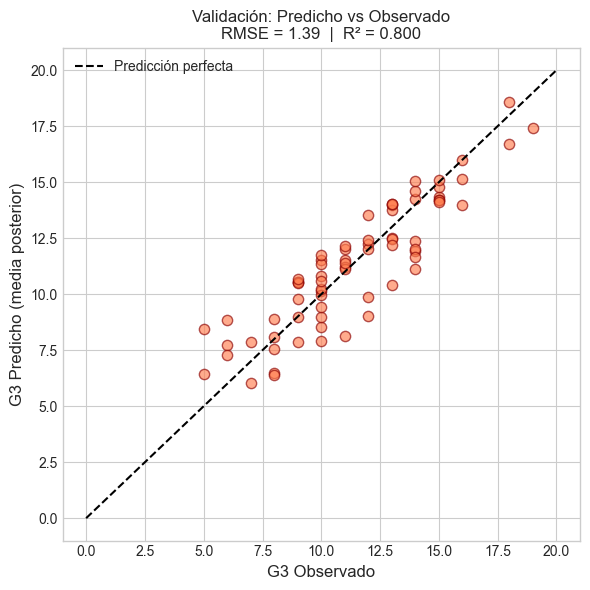

In [12]:
# Predicciones en conjunto de validación (usando medias posteriores)
alpha_post = float(trace.posterior['alpha'].values.mean())
beta_post  = trace.posterior['beta'].values.mean(axis=(0, 1))  # shape (n_features,)

y_pred = alpha_post + X_test_std @ beta_post

# Métricas
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("=" * 42)
print("  MÉTRICAS EN CONJUNTO DE VALIDACIÓN")
print("=" * 42)
print(f"  MAE  : {mae:.3f} puntos")
print(f"  RMSE : {rmse:.3f} puntos")
print(f"  R²   : {r2:.3f}")
print("=" * 42)

# Gráfico predicho vs observado
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred, alpha=0.65, color='coral', edgecolors='darkred', s=55)
ax.plot([0, 20], [0, 20], 'k--', lw=1.5, label='Predicción perfecta')
ax.set_xlabel('G3 Observado', fontsize=12)
ax.set_ylabel('G3 Predicho (media posterior)', fontsize=12)
ax.set_title(f'Validación: Predicho vs Observado\nRMSE = {rmse:.2f}  |  R² = {r2:.3f}', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

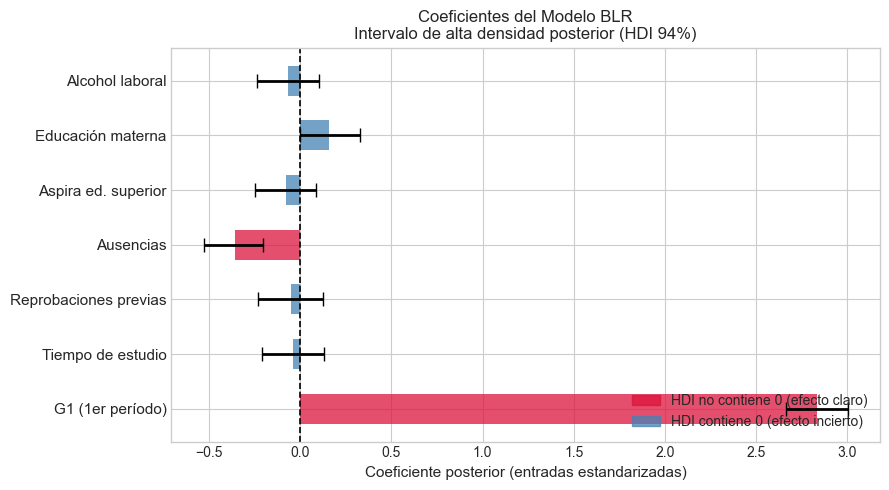


Interpretación de coeficientes (efecto por 1 desv. estándar de cada predictor):
  (*) G1 (1er período)              : +2.830  HDI 94% [+2.662, +3.002]
      Tiempo de estudio             : -0.037  HDI 94% [-0.207, +0.128]
      Reprobaciones previas         : -0.048  HDI 94% [-0.232, +0.124]
  (*) Ausencias                     : -0.357  HDI 94% [-0.529, -0.202]
      Aspira ed. superior           : -0.076  HDI 94% [-0.247, +0.089]
      Educación materna             : +0.160  HDI 94% [-0.001, +0.330]
      Alcohol laboral               : -0.068  HDI 94% [-0.235, +0.102]


In [13]:
# Gráfico de coeficientes (Forest plot manual con HDI 94%)
betas_samples = trace.posterior['beta'].values.reshape(-1, n_features)  # (chains*draws, p)
beta_means = betas_samples.mean(axis=0)
beta_hdi   = az.hdi(betas_samples, hdi_prob=0.94)  # shape (p, 2)

# Color rojo si el HDI no incluye el cero (predictor significativo)
colors = [
    'crimson' if (lo > 0 or hi < 0) else 'steelblue'
    for lo, hi in zip(beta_hdi[:, 0], beta_hdi[:, 1])
]

fig, ax = plt.subplots(figsize=(9, 5))
for i, (label, mean, hdi_vals, color) in enumerate(
        zip(FEATURE_LABELS, beta_means, beta_hdi, colors)):
    ax.barh(i, mean, color=color, alpha=0.75, height=0.55)
    ax.errorbar(mean, i,
                xerr=[[mean - hdi_vals[0]], [hdi_vals[1] - mean]],
                fmt='none', color='black', capsize=5, lw=2)

ax.axvline(0, color='black', linestyle='--', lw=1.2)
ax.set_yticks(range(n_features))
ax.set_yticklabels(FEATURE_LABELS, fontsize=11)
ax.set_xlabel('Coeficiente posterior (entradas estandarizadas)', fontsize=11)
ax.set_title('Coeficientes del Modelo BLR\nIntervalo de alta densidad posterior (HDI 94%)', fontsize=12)

red_p  = mpatches.Patch(color='crimson',  alpha=0.75, label='HDI no contiene 0 (efecto claro)')
blue_p = mpatches.Patch(color='steelblue', alpha=0.75, label='HDI contiene 0 (efecto incierto)')
ax.legend(handles=[red_p, blue_p], loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

print("\nInterpretación de coeficientes (efecto por 1 desv. estándar de cada predictor):")
for label, m, hdi_vals in zip(FEATURE_LABELS, beta_means, beta_hdi):
    sig = "(*)" if (hdi_vals[0] > 0 or hdi_vals[1] < 0) else "   "
    print(f"  {sig} {label:<30}: {m:+.3f}  HDI 94% [{hdi_vals[0]:+.3f}, {hdi_vals[1]:+.3f}]")

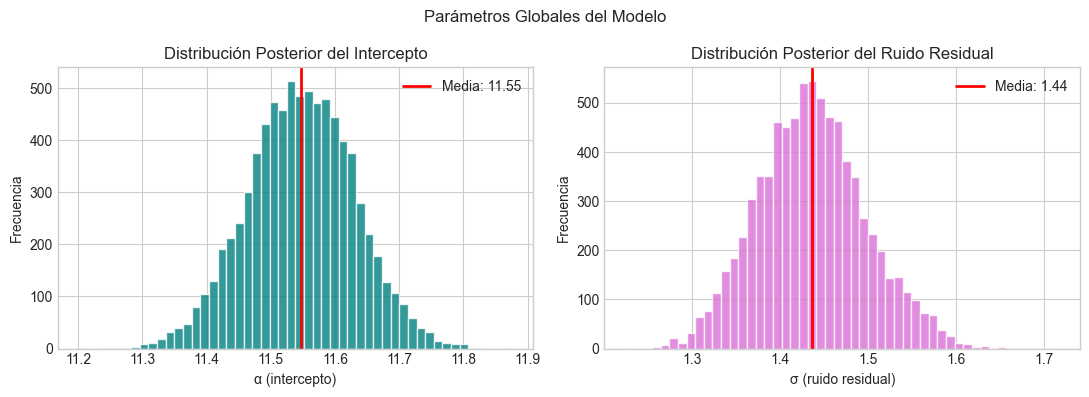

In [14]:
# Distribución posterior del intercepto y sigma
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Alpha posterior
alpha_samples = trace.posterior['alpha'].values.flatten()
axes[0].hist(alpha_samples, bins=50, color='teal', edgecolor='white', alpha=0.8)
axes[0].axvline(alpha_samples.mean(), color='red', lw=2,
                label=f'Media: {alpha_samples.mean():.2f}')
axes[0].set_xlabel('α (intercepto)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución Posterior del Intercepto')
axes[0].legend()

# Sigma posterior
sigma_samples = trace.posterior['sigma'].values.flatten()
axes[1].hist(sigma_samples, bins=50, color='orchid', edgecolor='white', alpha=0.8)
axes[1].axvline(sigma_samples.mean(), color='red', lw=2,
                label=f'Media: {sigma_samples.mean():.2f}')
axes[1].set_xlabel('σ (ruido residual)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución Posterior del Ruido Residual')
axes[1].legend()

plt.suptitle('Parámetros Globales del Modelo', fontsize=12)
plt.tight_layout()
plt.show()

---

## Conclusiones

### Sobre el rendimiento del modelo

El modelo de Regresión Lineal Bayesiana (RLB) explica el **80% de la variabilidad** en la calificación final (R² = 0.80) con un error promedio de **1.13 puntos** (MAE) sobre una escala de 0–20. El ruido residual posterior es σ = 1.44 puntos, lo que refleja la variabilidad natural que el modelo no captura con los predictores disponibles.

### Sobre los predictores

Solo **dos de los siete predictores** tienen un efecto claro según el HDI 94%:

- **G1** (β = +2.83): la calificación del primer período domina la predicción. El rendimiento pasado es el mejor predictor del rendimiento futuro.
- **Ausencias** (β = −0.36): reducen la calificación final incluso controlando por G1. Cada desviación estándar extra (~8 faltas) representa −0.36 puntos en G3.

El resto de los predictores (reprobaciones, tiempo de estudio, alcohol, educación materna, aspiración académica) tienen HDI que incluye el cero: su efecto ya está capturado por G1 o no es discernible con el tamaño muestral disponible.

### Sobre la incertidumbre

Una contribución central del enfoque Bayesiano es que **toda estimación viene acompañada de su incertidumbre**. Los HDI permiten responder preguntas como "¿cuánto puede variar el efecto de las ausencias?" de forma directa y probabilística, algo que los p-valores no proveen. La convergencia perfecta del MCMC (R-hat = 1.0, ESS > 13,000 en todas las cadenas) garantiza que estas distribuciones son fiables.

### Limitaciones

- **Dependencia de G1**: el modelo requiere conocer el primer período, limitando su uso para intervenciones muy tempranas.
- **Linealidad e independencia**: no captura interacciones entre predictores.
- **Desertores excluidos**: los 38 estudiantes con G3 = 0 requieren un modelo separado.
- **Escala de G3**: siendo discreta (0–20), una distribución truncada u ordinal sería más precisa que la Gaussiana.

### Trabajo futuro

- Modelo jerárquico por escuela (GP vs MS).
- *Hurdle model* para incluir desertores.
- Aplicar el mismo framework al dataset de Portugués para comparar efectos entre asignaturas.